In [31]:
import  tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [32]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [33]:
X_test.shape

(10000, 32, 32, 3)

In [34]:
X_train.shape

(50000, 32, 32, 3)

In [35]:
y_train.shape

(50000, 1)

In [36]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [37]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [38]:
y_test = y_test.reshape(-1,)

In [39]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [40]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

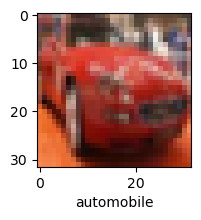

In [41]:
plot_sample(X_train, y_train, 5)

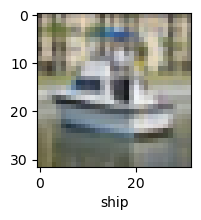

In [42]:
plot_sample(X_train, y_train, 501)

In [43]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [44]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.3532 - loss: 1.8117
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.4283 - loss: 1.6232
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.4570 - loss: 1.5442
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.4750 - loss: 1.4826
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.4958 - loss: 1.4332


In [45]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print('classification report: \n', classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.45      0.67      0.54      1000
           1       0.64      0.58      0.61      1000
           2       0.38      0.36      0.37      1000
           3       0.34      0.37      0.36      1000
           4       0.55      0.23      0.32      1000
           5       0.39      0.36      0.37      1000
           6       0.47      0.64      0.54      1000
           7       0.48      0.63      0.55      1000
           8       0.60      0.58      0.59      1000
           9       0.68      0.41      0.51      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.48     10000
weighted avg       0.50      0.48      0.48     10000



In [46]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

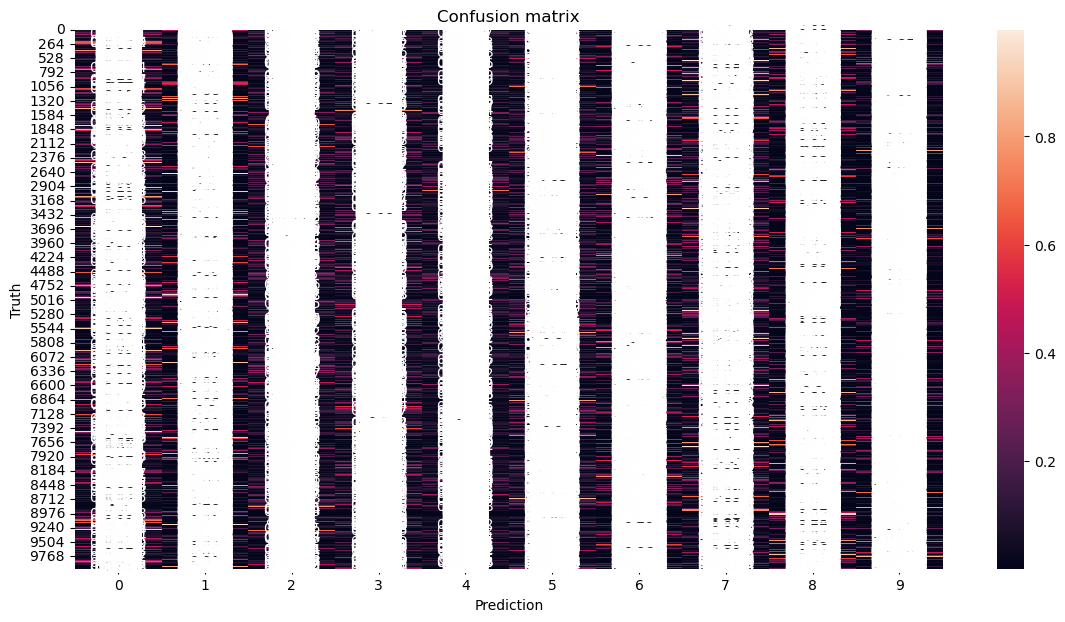

In [47]:
plt.figure(figsize = (14,7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix')
plt.show

In [48]:
cnn = models.Sequential([
    layers.Input(shape=(32,32,3)),         
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [49]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [50]:
history = cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.4562 - loss: 1.5064 - val_accuracy: 0.5668 - val_loss: 1.2356
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.5971 - loss: 1.1455 - val_accuracy: 0.6266 - val_loss: 1.0737
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6472 - loss: 1.0107 - val_accuracy: 0.6414 - val_loss: 1.0325
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6788 - loss: 0.9271 - val_accuracy: 0.6611 - val_loss: 0.9600
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7021 - loss: 0.8631 - val_accuracy: 0.6510 - val_loss: 1.0100
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7211 - loss: 0.8072 - val_accuracy: 0.6842 - val_loss: 0.9248
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7373 - loss: 0.7581 - val_accuracy: 0.6868 - val_loss: 0.9306
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7522 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


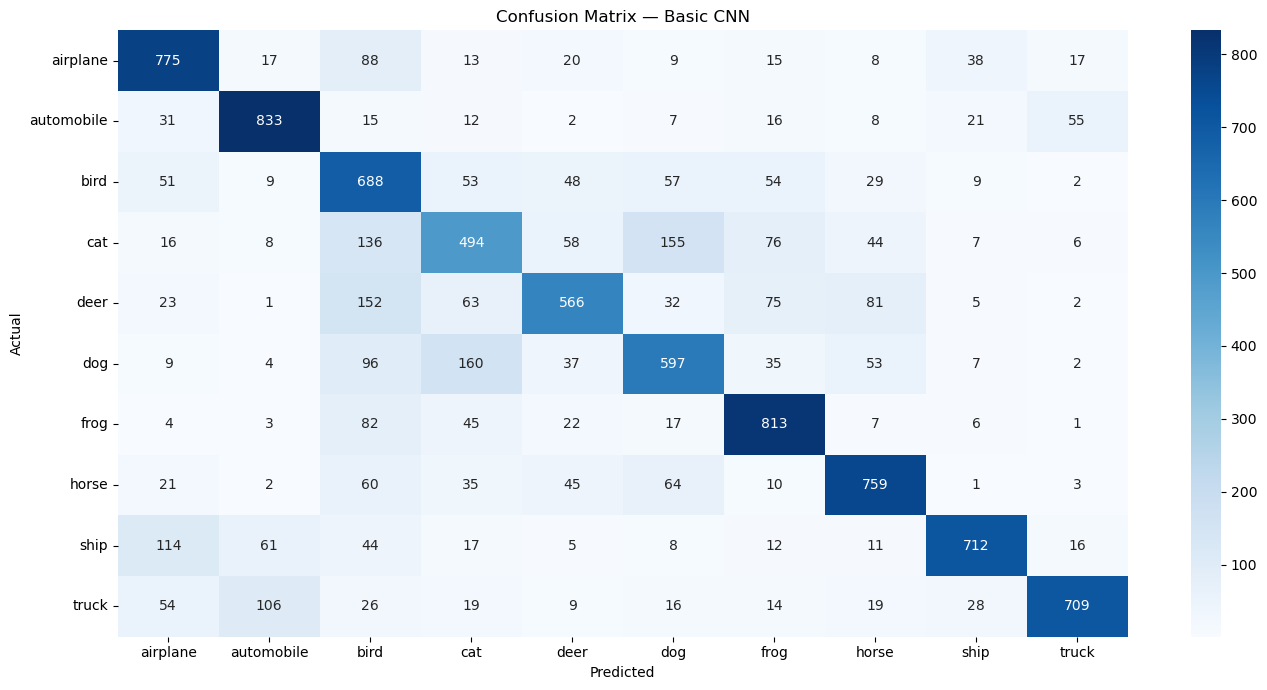

In [51]:
# fix Confusion Matrix version from claude

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from your CNN
y_pred = cnn.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

# Correct confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Basic CNN')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png')   # saves image for your report
plt.show()

In [52]:
# fix Classification Report version from claude

print("Classification Report — Basic CNN")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=classes))

Classification Report — Basic CNN
              precision    recall  f1-score   support

    airplane       0.71      0.78      0.74      1000
  automobile       0.80      0.83      0.82      1000
        bird       0.50      0.69      0.58      1000
         cat       0.54      0.49      0.52      1000
        deer       0.70      0.57      0.62      1000
         dog       0.62      0.60      0.61      1000
        frog       0.73      0.81      0.77      1000
       horse       0.74      0.76      0.75      1000
        ship       0.85      0.71      0.78      1000
       truck       0.87      0.71      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.71      0.69      0.70     10000
weighted avg       0.71      0.69      0.70     10000



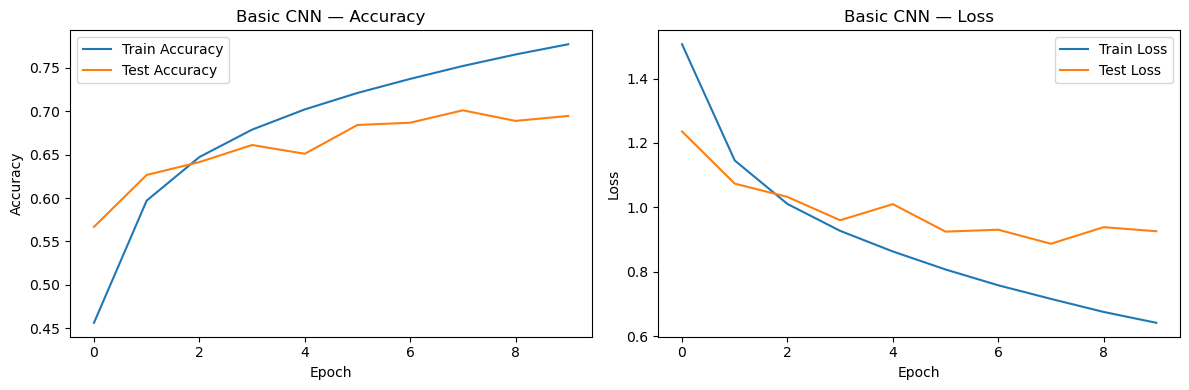

In [53]:
# added step to get cnn_training_curves.png for report

# Plot Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Basic CNN — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Basic CNN — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png')   # saves for report
plt.show()

In [54]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6946 - loss: 0.9259


[0.9258871078491211, 0.694599986076355]

In [55]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[7.8825001e-04, 1.1806685e-04, 1.6218282e-02, 8.4506869e-01,
        2.9810369e-03, 4.9197577e-02, 2.0586219e-02, 3.7794365e-03,
        6.1003793e-02, 2.5866917e-04],
       [5.7695383e-01, 3.7365179e-03, 6.4285079e-05, 1.0247080e-06,
        5.9031873e-07, 1.0450231e-08, 6.5657093e-09, 3.6239345e-07,
        4.1914326e-01, 1.0013516e-04],
       [3.9114919e-02, 7.2222728e-01, 5.8818539e-04, 9.1139833e-03,
        2.6292717e-03, 2.1031212e-04, 1.0484759e-04, 1.7900381e-02,
        2.0191981e-01, 6.1909328e-03],
       [9.6228057e-01, 1.6392163e-03, 1.7589763e-02, 8.0715770e-05,
        1.5358967e-04, 1.5640279e-06, 6.7904984e-06, 2.5774723e-05,
        1.8176874e-02, 4.5012363e-05],
       [1.4598781e-05, 1.2777855e-05, 2.5043070e-02, 2.9531389e-02,
        1.1977050e-01, 2.5859221e-03, 8.2272464e-01, 2.8903480e-04,
        2.5616942e-05, 2.5024947e-06]], dtype=float32)

In [56]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 0, 1, 0, 6]

In [57]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

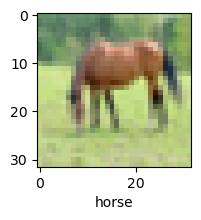

In [58]:
plot_sample(X_test, y_test, 60)

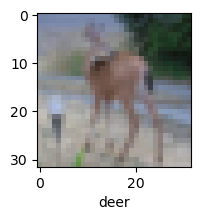

In [59]:
plot_sample(X_test, y_test, 100)

In [60]:
classes[y_classes[60]]

'horse'

In [61]:
# CNN Enhancement

In [62]:
# Step 1 — Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)
datagen.fit(X_train)

In [63]:
# Step 2 — Build the Enhanced Model
new_cnn = models.Sequential([
    layers.Input(shape=(32,32,3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

new_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,458 (2.55 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [64]:
# Step 3 — Compile & Train
new_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_new = new_cnn.fit(datagen.flow(X_train, y_train, batch_size=64),
                           epochs=20,
                           validation_data=(X_test, y_test))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 195ms/step - accuracy: 0.4167 - loss: 1.7074 - val_accuracy: 0.4254 - val_loss: 2.1248
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 152ms/step - accuracy: 0.5743 - loss: 1.1891 - val_accuracy: 0.5999 - val_loss: 1.1673
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.6425 - loss: 1.0180 - val_accuracy: 0.6575 - val_loss: 1.0462
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 127s 162ms/step - accuracy: 0.6753 - loss: 0.9303 - val_accuracy: 0.6974 - val_loss: 0.8736
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.6958 - loss: 0.8594 - val_accuracy: 0.7109 - val_loss: 0.8333
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 127s 163ms/step - accuracy: 0.7178 - loss: 0.8112 - val_accuracy: 0.7030 - val_loss: 0.8762
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step - accuracy: 0.7312 - loss: 0.7680 - val_accuracy: 0.7191 - val_loss: 0.8159
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 158ms/step - accuracy: 0.7438 -

In [65]:
# Step 4 — Evaluate New CNN
loss_new, acc_new = new_cnn.evaluate(X_test, y_test)
print(f"New CNN Test Accuracy: {acc_new*100:.2f}%")
print(f"New CNN Test Loss:     {loss_new:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7864 - loss: 0.6415
New CNN Test Accuracy: 78.64%
New CNN Test Loss:     0.6415


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


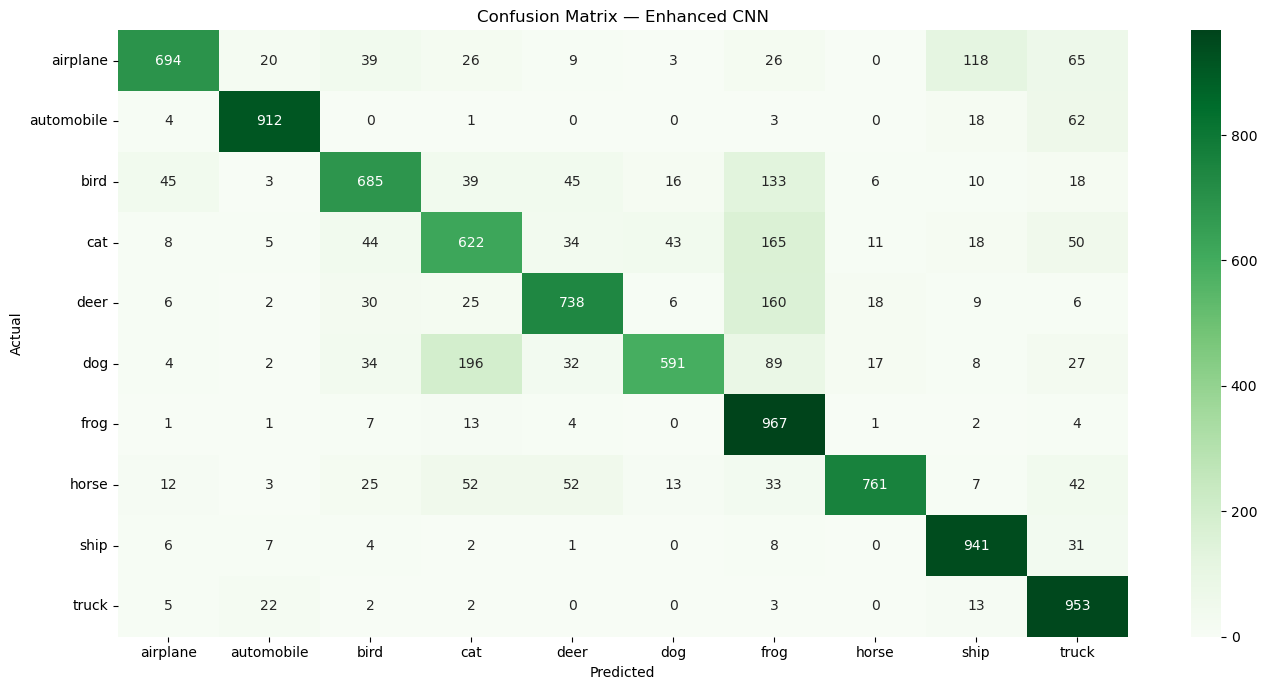

Classification Report — Enhanced CNN
              precision    recall  f1-score   support

    airplane       0.88      0.69      0.78      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.79      0.69      0.73      1000
         cat       0.64      0.62      0.63      1000
        deer       0.81      0.74      0.77      1000
         dog       0.88      0.59      0.71      1000
        frog       0.61      0.97      0.75      1000
       horse       0.93      0.76      0.84      1000
        ship       0.82      0.94      0.88      1000
       truck       0.76      0.95      0.84      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.78     10000
weighted avg       0.81      0.79      0.78     10000



In [66]:
# Step 5 — Confusion Matrix for New CNN
y_pred_new = new_cnn.predict(X_test)
y_pred_new_classes = [np.argmax(element) for element in y_pred_new]

cm_new = confusion_matrix(y_test, y_pred_new_classes)

plt.figure(figsize=(14,7))
sns.heatmap(cm_new, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Greens')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Enhanced CNN')
plt.tight_layout()
plt.savefig('confusion_matrix_new_cnn.png')
plt.show()

print("Classification Report — Enhanced CNN")
print("="*50)
print(classification_report(y_test, y_pred_new_classes, target_names=classes))

In [67]:
# Step 6 — Compare Both Models Side by Side
loss_basic, acc_basic = cnn.evaluate(X_test, y_test)

print("\n" + "="*45)
print(f"{'Model':<20} {'Accuracy':>10} {'Loss':>10}")
print("="*45)
print(f"{'Basic CNN':<20} {acc_basic*100:>9.2f}% {loss_basic:>10.4f}")
print(f"{'Enhanced CNN':<20} {acc_new*100:>9.2f}% {loss_new:>10.4f}")
print("="*45)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6946 - loss: 0.9259

Model                  Accuracy       Loss
Basic CNN                69.46%     0.9259
Enhanced CNN             78.64%     0.6415


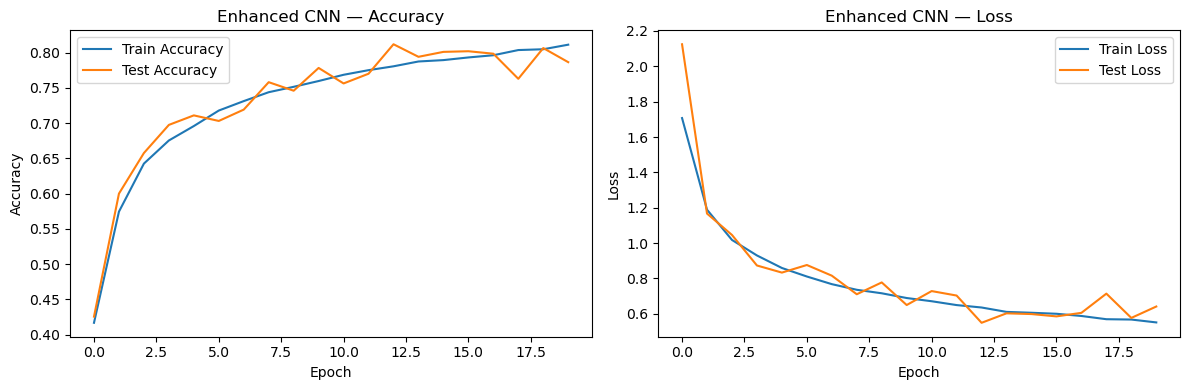

In [68]:
# Step 7 — Training Curves for New CNN
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_new.history['accuracy'], label='Train Accuracy')
plt.plot(history_new.history['val_accuracy'], label='Test Accuracy')
plt.title('Enhanced CNN — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_new.history['loss'], label='Train Loss')
plt.plot(history_new.history['val_loss'], label='Test Loss')
plt.title('Enhanced CNN — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('new_cnn_training_curves.png')
plt.show()